<a href="https://colab.research.google.com/github/olahiru176-svg/QUiz/blob/main/CH4130_Tutorial2_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="font-size:30px; color:black;">
    CH4130 Process Optimization </p>
<p style="font-size:25px; color:black;">
Tutorial 2: Exploratory Data Analysis (EDA) and Correlations
</p>


This tutorial is to explore data visualization and correlation analysis using Python. You can use any other tools (even Excel) for this purpose, but Python is highly encouraged.

Use vibe coding if you are not not familiar with Python.

**About Data:**

This is a synthetic dataset simulating the yield of a reactor. The variables are;
- Temperature
- Pressure
- Catalyst Concentration
- Feed Flow Rate
- Catalyst Supplier
- Yield

# Read Reactor Data Data


Data Location: https://raw.githubusercontent.com/dissabnd/CH4130-Process-Optimization/refs/heads/main/data/reactor_data.csv

**Prompt:**

Load data into df from https://raw.githubusercontent.com/dissabnd/CH4130-Process-Optimization/refs/heads/main/data/reactor_data.csv


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('./data/reactor_data.csv')
df

,Temperature (°C),Pressure (bar),Catalyst Concentration (wt%),Feed Flow Rate (L/min),Catalyst Supplier,Yield (%)
0,206.22,6.32,2.08,10.55,A,67.77
1,246.55,4.98,2.80,10.12,A,86.93
2,231.24,4.79,2.81,9.85,A,80.45
3,221.91,5.48,2.96,10.81,A,77.90
4,190.92,6.47,3.09,9.22,A,84.60
...,...,...,...,...,...,...
145,182.58,5.54,3.42,9.95,C,74.18
146,222.67,6.04,3.48,10.34,A,88.06
147,215.19,4.93,3.13,9.34,B,77.71
148,183.60,5.75,2.56,9.38,C,68.84


In [ ]:
df.columns

Index(['Temperature (°C)', 'Pressure (bar)', 'Catalyst Concentration (wt%)',
       'Feed Flow Rate (L/min)', 'Catalyst Supplier', 'Yield (%)'],
      dtype='object')

# Part 1: Descriptive Stats (mean, median and SD)

**Prompt:**

Can you give me a python code to generate summary stats of below table?

In [ ]:
# Generate summary statistics
summary_stats = df.describe()

summary_stats

,Temperature (°C),Pressure (bar),Catalyst Concentration (wt%),Feed Flow Rate (L/min),Yield (%)
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,213.102000,5.534667,2.744067,10.051200,76.130733
std,20.756918,0.582709,0.451812,0.608127,6.770026
min,180.390000,4.510000,2.020000,9.020000,60.000000
25%,195.032500,4.997500,2.372500,9.527500,71.015000
50%,211.365000,5.610000,2.755000,10.065000,76.390000
75%,232.477500,6.012500,3.130000,10.627500,81.210000
max,249.080000,6.480000,3.490000,11.000000,95.000000


# Part 2: Data Visualization

## 2.1 Data Distributions with Histogram

**Prompt:**

Give the python code for below. Generate histogram plots for each variables using seaborn. Create a figure, then do subplots.

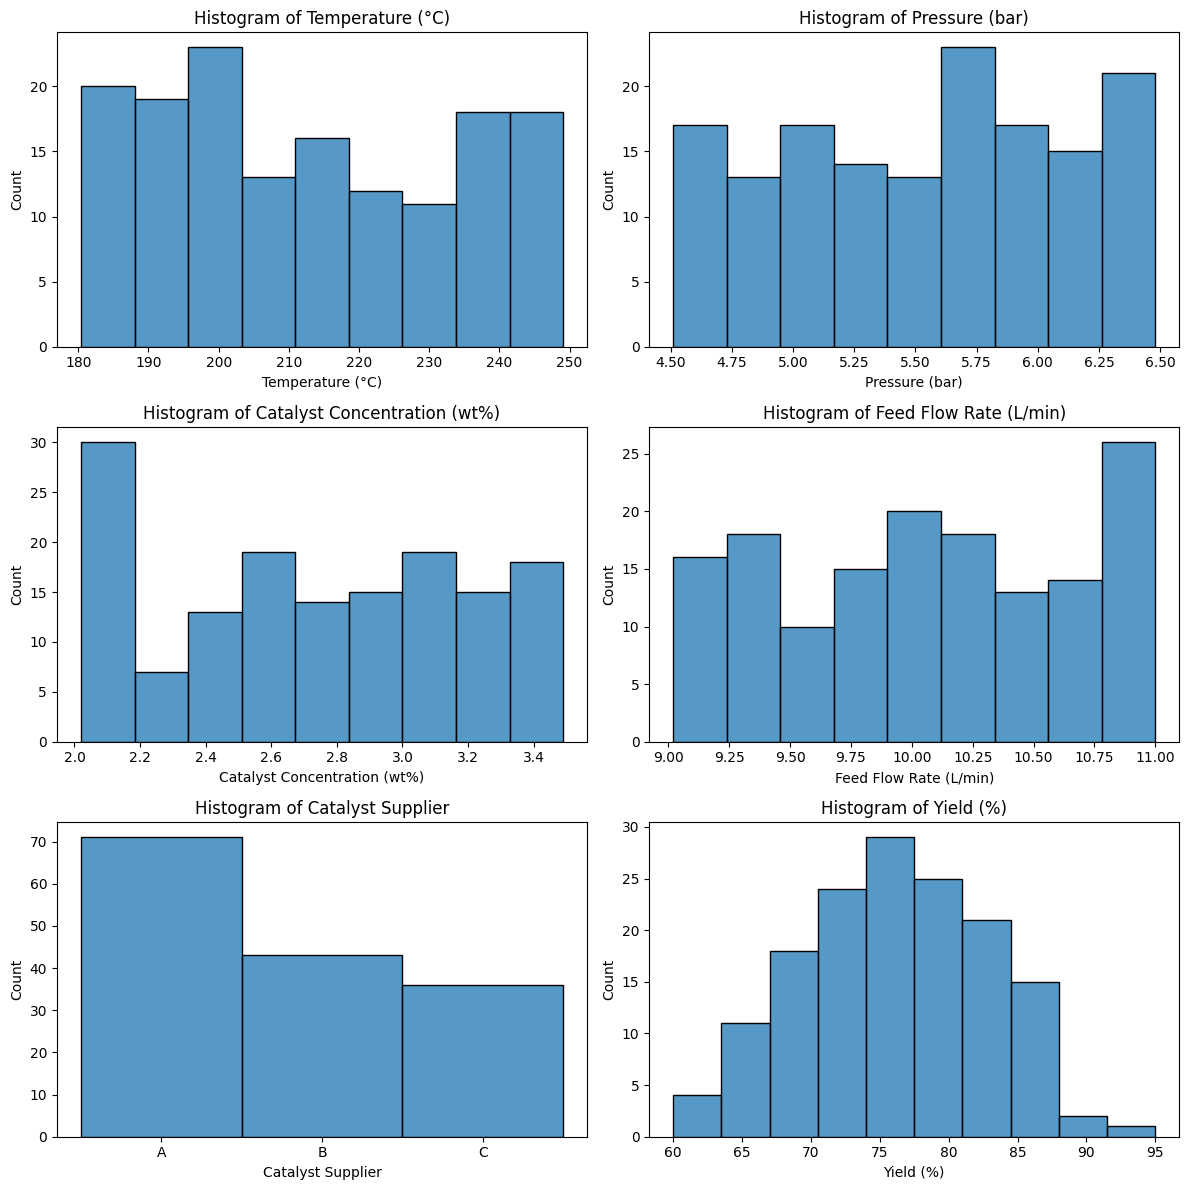

In [ ]:
# Set up figure and axes
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

# Iterate through columns and plot histograms
for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=False, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')

# Hide the last unused subplot if odd number of variables
if len(df.columns) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## 2.2 Data distributions with box plot

**Prompt:**

Give the python code for below. Generate box plots for each numerical variables using seaborn. Create a figure, then do subplots.

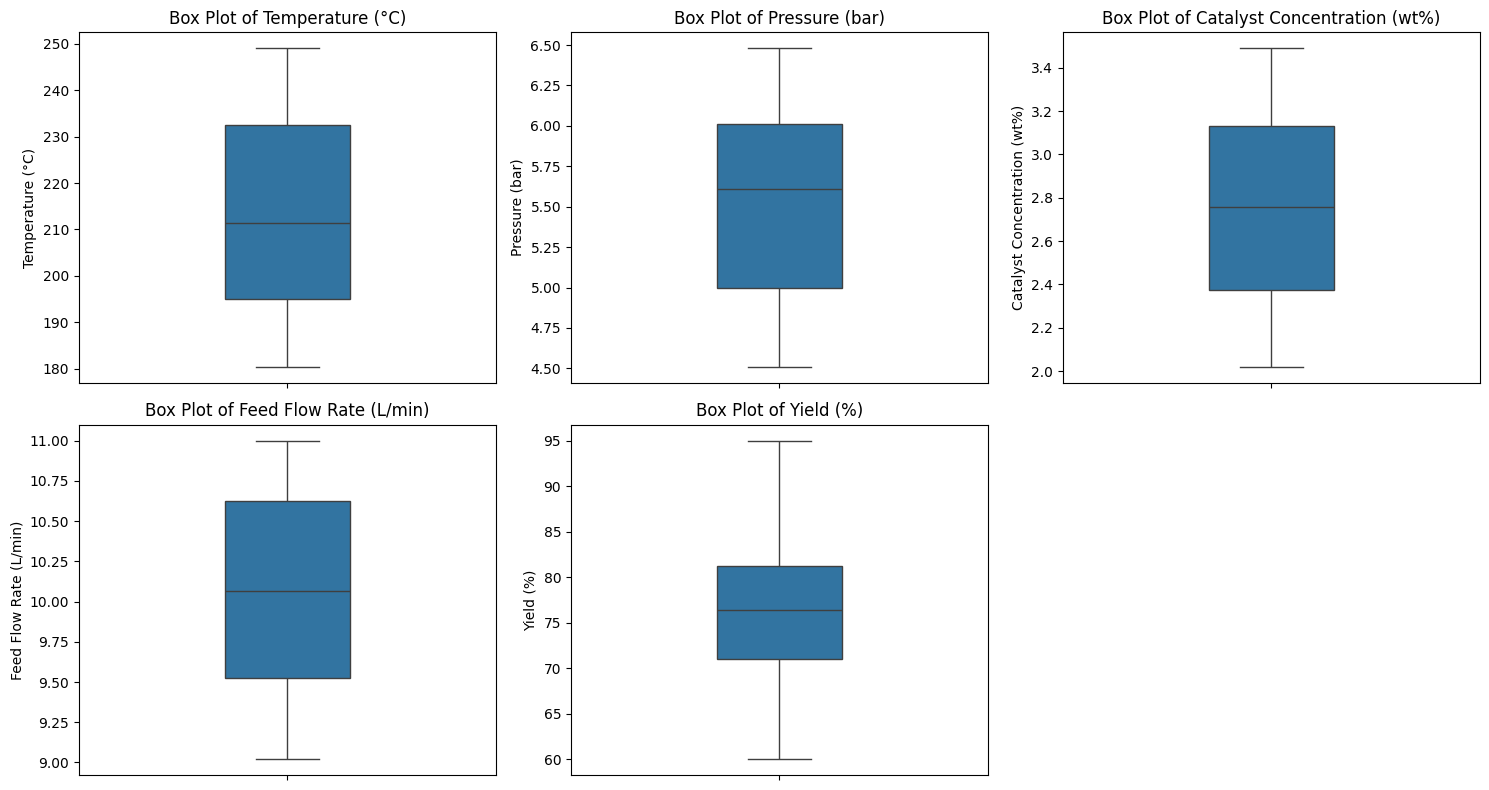

In [ ]:
# Select numerical columns
num_cols = ['Temperature (°C)', 'Pressure (bar)', 'Catalyst Concentration (wt%)', 'Feed Flow Rate (L/min)', 'Yield (%)']

# Create figure and subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

# Generate box plots
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], width=0.3)
    axes[i].set_title(f'Box Plot of {col}')

# Remove empty subplot if any
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## 2.3 Relationship between Reactor Yield and Other Variables

### 2.3.1 XY scatter plot

**Prompt:**

Give the python code for below. Generate xy scatter plot using Yield as y variable and other numerical var as x. Create a figure and then do subplots. Use regplot.

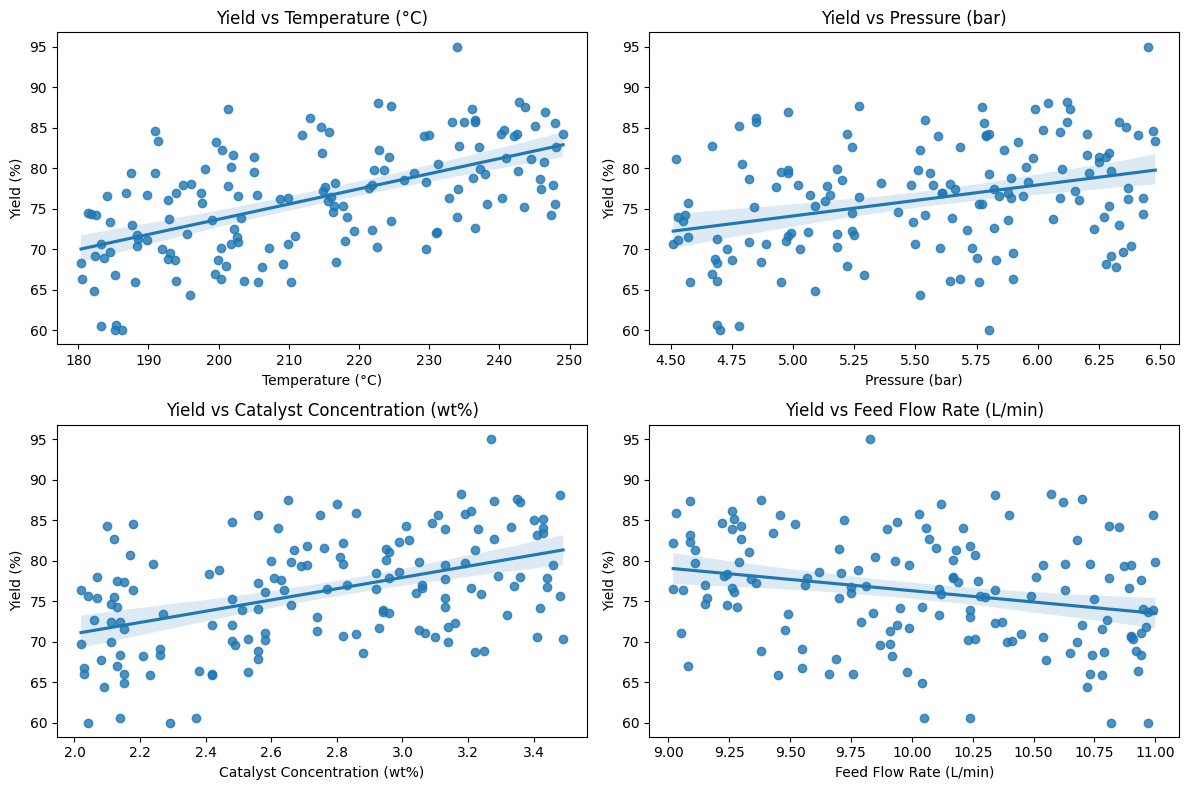

In [ ]:
# Select numerical columns (excluding Yield)
x_cols = ['Temperature (°C)', 'Pressure (bar)', 'Catalyst Concentration (wt%)', 'Feed Flow Rate (L/min)']

# Create figure and subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()

# Generate scatter plots with regression line
for i, col in enumerate(x_cols):
    sns.regplot(x=df[col], y=df['Yield (%)'], ax=axes[i])
    axes[i].set_title(f'Yield vs {col}')

plt.tight_layout()
plt.show()

### 2.3.2 Yield and Supplier - Bar plot

***Prompt:**

Create a bar plot using catalyst supplier as x and yiled as y. Use standard error in error bars. Use sns barplot option

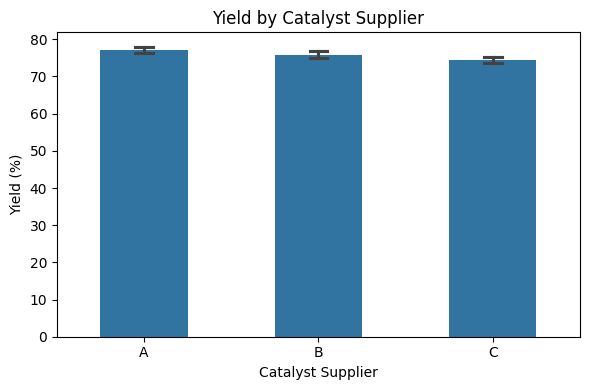

In [ ]:
# Create bar plot with standard error
plt.figure(figsize=(6, 4))
sns.barplot(x='Catalyst Supplier', y='Yield (%)', data=df, errorbar='se',capsize=0.1, width=0.5)
plt.title('Yield by Catalyst Supplier')
plt.tight_layout()
plt.show()

### 2.3.3 Yield and Supplier - Violin plot

***Prompt:**

Create a violin plot using catalyst supplier as x and yiled as y. Use standard error in error bars. Use sns barplot option

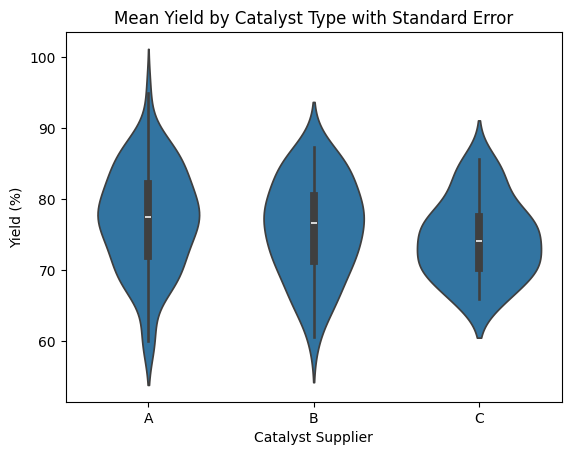

In [ ]:
sns.violinplot(x='Catalyst Supplier', y='Yield (%)', data=df, width=0.75)
plt.xlabel('Catalyst Supplier')
plt.ylabel('Yield (%)')
plt.title('Mean Yield by Catalyst Type with Standard Error')
plt.show()

# Part 3: Correlatoin Analysis

## 3.1 Pearson correlation

**Promopt:**

I want to create correlation matrix using Pearson correlation

In [ ]:
# Select numerical columns
num_cols = ['Temperature (°C)', 'Pressure (bar)', 'Catalyst Concentration (wt%)', 'Feed Flow Rate (L/min)', 'Yield (%)']

# Calculate Pearson correlation matrix
corr_matrix = df[num_cols].corr(method='pearson')

corr_matrix

,Temperature (°C),Pressure (bar),Catalyst Concentration (wt%),Feed Flow Rate (L/min),Yield (%)
Temperature (°C),1.000000,0.036120,-0.136279,-0.021430,0.574045
Pressure (bar),0.036120,1.000000,-0.036880,-0.074675,0.329049
Catalyst Concentration (wt%),-0.136279,-0.036880,1.000000,0.009926,0.463196
Feed Flow Rate (L/min),-0.021430,-0.074675,0.009926,1.000000,-0.250595
Yield (%),0.574045,0.329049,0.463196,-0.250595,1.000000


## 3.2 Correlation heat map

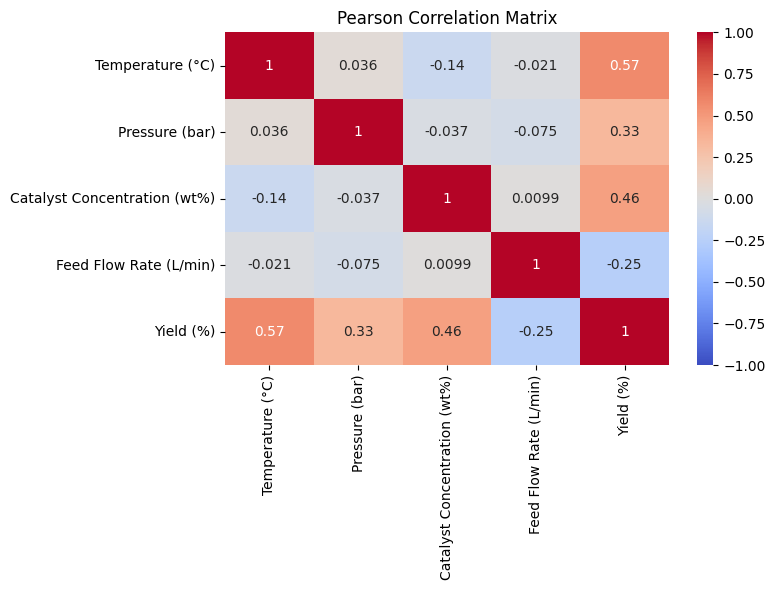

In [ ]:
# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()